In [1]:
!	pip install interpret
!	pip install sklearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 75.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 22.2 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size

In [2]:
import numpy as np
import pandas as pd
from interpret.glassbox import ExplainableBoostingRegressor as EBR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso, lasso_path
from matplotlib import pyplot as plt
from collections import defaultdict
# Read in sc data (analysis adapted from "Computer Age Statistical Inference")
filename = "unique_m.csv"
sc = pd.read_csv(filename)
sc.head() # inspect first few rows

,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
0,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,29.0,Ba0.2La1.8Cu1O4
1,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,26.0,Ba0.1La1.9Ag0.1Cu0.9O4
2,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,19.0,Ba0.1La1.9Cu1O4
3,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,22.0,Ba0.15La1.85Cu1O4
4,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,23.0,Ba0.3La1.7Cu1O4


In [13]:
#random sample
sc_sampled = sc.sample(n=5000, random_state=42)

In [14]:
# 1. seperate feature & target
X = sc_sampled.iloc[:, :-2]
y = sc_sampled.iloc[:, -2]

# 2. split the dataset
# test_size=0.2 20% as test dataset
X_trn, X_tst, y_trn, y_tst = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# 3. （可选）将特征和目标重新合并为完整的DataFrame，便于后续处理
train_df = pd.concat([X_trn, y_trn], axis=1)
test_df = pd.concat([X_tst, y_tst], axis=1)

# 4. check split result
print(f"原始数据集形状: {sc.shape}")
print(f"训练集形状: {train_df.shape}")
print(f"测试集形状: {test_df.shape}")
print(f"测试集占比: {len(test_df) / len(sc):.1%}")

原始数据集形状: (21263, 88)
训练集形状: (4000, 87)
测试集形状: (1000, 87)
测试集占比: 4.7%


In [15]:
# Fit an EBM
ebm = EBR(inner_bags=5, outer_bags=5,interactions=10)
ebm.fit(X_trn, y=y_trn)

ExplainableBoostingRegressor(inner_bags=5, interactions=10, outer_bags=5)

In [16]:
# Convert train/test sets into their associated term contributions
X_trn_tc = ebm.eval_terms(X_trn)
X_tst_tc = ebm.eval_terms(X_tst)
# Fit LASSO path and grab alpha values
ebm_lasso_path = lasso_path(X_trn_tc, y=y_trn, positive=True)
alphas = ebm_lasso_path[0]
# Fit a LASSO for each alpha; compute test MSE and number of non-zero coefs
mses = []
nterms = []
for alpha in alphas:
    _lasso = Lasso(alpha=alpha, positive=True)
    _lasso.fit(X_trn_tc, y=y_trn)
    _mse = mean_squared_error(y_tst, y_pred=_lasso.predict(X_tst_tc))
    mses.append(_mse)
    nterms.append(np.count_nonzero(_lasso.coef_))

In [17]:
# original EBM mse
y_pred_ebm = ebm.predict(X_tst)
mse_original = mean_squared_error(y_tst, y_pred_ebm)

# tolerence for MSE
tolerance = 20.0
threshold = mse_original + tolerance

# find the index of all alphas which satisfy MSE ≤ threshold
valid_indices = [i for i, mse_val in enumerate(mses) if mse_val <= threshold]

if valid_indices:
    # 选第一个（即 alpha 最大的那个，因 alphas 降序）
    best_idx = valid_indices[0]
    alpha_best = alphas[best_idx]
    print(f"[LASSO Selection] Chose alpha={alpha_best:.2e} (MSE={mses[best_idx]:.3f} ≤ {threshold:.3f}, n_terms={nterms[best_idx]})")
else:
    # 回退到 MSE 最小（理论上不应发生）
    best_idx = np.argmin(mses)
    alpha_best = alphas[best_idx]
    print(f"[LASSO Selection] No alpha within tolerance. Fallback to best MSE: alpha={alpha_best:.2e}")

# === train LASSO model ===
ebm_lasso = Lasso(alpha=alpha_best, positive=True)
ebm_lasso.fit(X_trn_tc, y=y_trn)


[LASSO Selection] Chose alpha=1.86e+00 (MSE=177.884 ≤ 178.306, n_terms=20)


Lasso(alpha=np.float64(1.8571826699121163), positive=True)

# 老式alpha选择法

In [ ]:
# Fit a LASSO using the "best" alpha
alpha_best = alphas[np.argmin(mses)]
ebm_lasso = Lasso(alpha=alpha_best, positive=True)
ebm_lasso.fit(X_trn_tc, y=y_trn)

Lasso(alpha=np.float64(0.347217273735672), positive=True)

In [ ]:
np.count_nonzero(ebm_lasso.coef_) # number of non-zero coefficients

86

In [ ]:
# Compare intercepts
ebm.intercept_, ebm_lasso.intercept_

(34.440247653750006, np.float64(34.440247653750006))

In [ ]:
# Rescale terms using LASSO coefficients
for idx, x in enumerate(ebm.term_names_):
    ebm.scale(idx, factor=ebm_lasso.coef_[idx])
    ebm.intercept_ = float(ebm_lasso.intercept_) # update intercept

In [ ]:
# Check term importance scores
term_imp = ebm.term_importances()
np.count_nonzero(term_imp) # terms with non-zero coefficients

44

In [ ]:
len(term_imp) - np.count_nonzero(term_imp) # terms with coefficient of zero

5

In [ ]:
# Remove unused terms (e.g., those with zero importance)
ebm.sweep()
len(ebm.term_names_) # sanity check (should only have 19 terms now)

44

# 绘图section

In [18]:
# Rescale terms using LASSO coefficients
for idx, x in enumerate(ebm.term_names_):
    ebm.scale(idx, factor=ebm_lasso.coef_[idx])
    ebm.intercept_ = float(ebm_lasso.intercept_) # update intercept
# Remove unused terms (e.g., those with zero importance)
ebm.sweep()
len(ebm.term_names_) # sanity check

20

In [19]:
# Check term importance scores for reduced EBM
# counting the intercept)
new_term_vi = pd.DataFrame({
'term' : ebm.term_names_, 'importance' : ebm.term_importances()
})
new_term_vi.sort_values(by=['importance'], ascending=False)

,term,importance
9,Ba,12.165175
4,Cu,11.361421
3,Ca,5.723181
7,Sr,3.725087
1,O,1.796452
12,O & Cu,1.790231
10,Pr,1.643412
11,Hg,1.058065
13,Ca & Cu,0.723663
14,Ca & Sr,0.676281


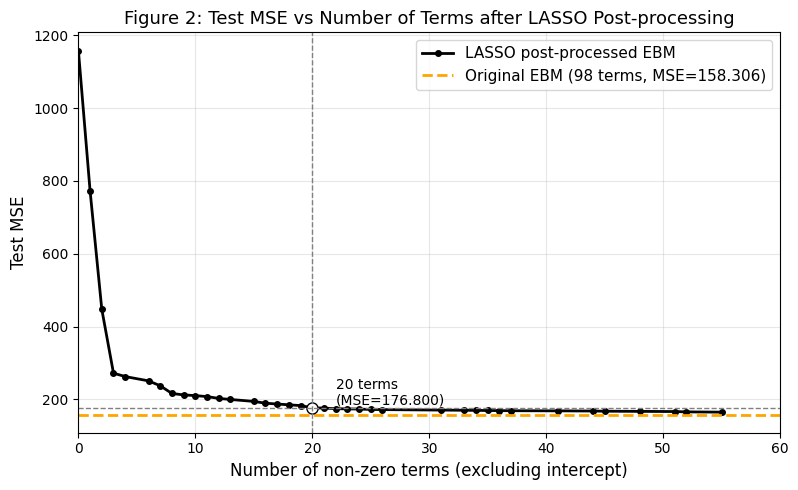

In [20]:
# Step 2: Sort by nterms in ascending order (LASSO path defaults to alpha descending,
# which usually means nterms ascending, but sorting is safer).
# Note: Multiple alphas might result in the same nterm; we keep the one with the minimum MSE.
mse_by_nterm = defaultdict(list)
for n, m in zip(nterms, mses):
    mse_by_nterm[n].append(m)

# Take the minimum test MSE for each term count (robust approach)
unique_nterms = sorted(mse_by_nterm.keys())
min_mses = [min(mse_by_nterm[n]) for n in unique_nterms]

# Step 3: Plotting
plt.figure(figsize=(8, 5))

# Main curve: LASSO path (Test MSE vs # terms)
plt.plot(unique_nterms, min_mses,
         marker='o', markersize=4, linewidth=2, color='black',
         label='LASSO post-processed EBM')

# Baseline: Original EBM horizontal line
plt.axhline(y=mse_original,
            color='orange', linestyle='--', linewidth=2,
            label=f'Original EBM (98 terms, MSE={mse_original:.3f})')

# Find the optimal point: Minimum number of non-zero terms where MSE <= original_ebm_mse + tolerance
tolerance = 20  # Allowance for a slight MSE increase
valid_indices = [i for i, (n, m) in enumerate(zip(unique_nterms, min_mses))
                if m <= mse_original + tolerance]

if valid_indices:
    # Select the index with the minimum number of non-zero terms
    best_idx = min(valid_indices, key=lambda i: unique_nterms[i])
    best_n = unique_nterms[best_idx]
    best_mse = min_mses[best_idx]

    # Highlight the best point
    plt.plot(best_n, best_mse, 'ko', markersize=8, markerfacecolor='white')
    plt.axhline(y=best_mse, color='gray', linestyle='--', linewidth=1)
    plt.axvline(x=best_n, color='gray', linestyle='--', linewidth=1)

    # Add text annotation
    plt.text(best_n + 2, best_mse + 0.002,
             f'{int(best_n)} terms\n(MSE={best_mse:.3f})',
             fontsize=10, ha='left', va='bottom')

# Decoration
plt.xlabel('Number of non-zero terms (excluding intercept)', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.title('Figure 2: Test MSE vs Number of Terms after LASSO Post-processing', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Optional: Limit x-axis range to highlight the first 50 terms/sparse region
plt.xlim(0, min(100, max(unique_nterms) + 5))

# Display or save
plt.show()
# plt.savefig('figure2.png', dpi=300, bbox_inches='tight')

计算标准mse，判断原始模型是否有效

In [12]:

# 1. 计算 MSE
mse = mean_squared_error(y_tst,  y_pred_ebm)

# 2. 计算 Var(y) —— 注意：用 y_true 的样本方差（ddof=0 或 1？见下方说明）
var_y = np.var(y_tst, ddof=0)  # 总体方差（sklearn R² 默认用 ddof=0）

# 3. 计算标准化 MSE = 1 - R²
normalized_mse = mse / var_y
r2 = 1 - normalized_mse

print(f"MSE = {mse:.4f}")
print(f"Var(y) = {var_y:.4f}")
print(f"Normalized MSE (1-R²) = {normalized_mse:.4f}")
print(f"R² = {r2:.4f}")

# 判断标准
if normalized_mse < 0.2:
    print("✅ 模型优秀！已捕捉 >80% 的信息 (1-R² < 0.2)")
else:
    print("⚠️ 模型有提升空间 (1-R² ≥ 0.2)")

MSE = 173.8490
Var(y) = 1142.0032
Normalized MSE (1-R²) = 0.1522
R² = 0.8478
✅ 模型优秀！已捕捉 >80% 的信息 (1-R² < 0.2)


In [21]:
# 3. 计算标准化 MSE = 1 - R²
normalized_mse = 176 / var_y
r2 = 1 - normalized_mse

print(f"MSE = {mse:.4f}")
print(f"Var(y) = {var_y:.4f}")
print(f"Normalized MSE (1-R²) = {normalized_mse:.4f}")
print(f"R² = {r2:.4f}")

# 判断标准
if normalized_mse < 0.2:
    print("✅ 模型优秀！已捕捉 >80% 的信息 (1-R² < 0.2)")
else:
    print("⚠️ 模型有提升空间 (1-R² ≥ 0.2)")

MSE = 173.8490
Var(y) = 1142.0032
Normalized MSE (1-R²) = 0.1541
R² = 0.8459
✅ 模型优秀！已捕捉 >80% 的信息 (1-R² < 0.2)


## 主效应特征图

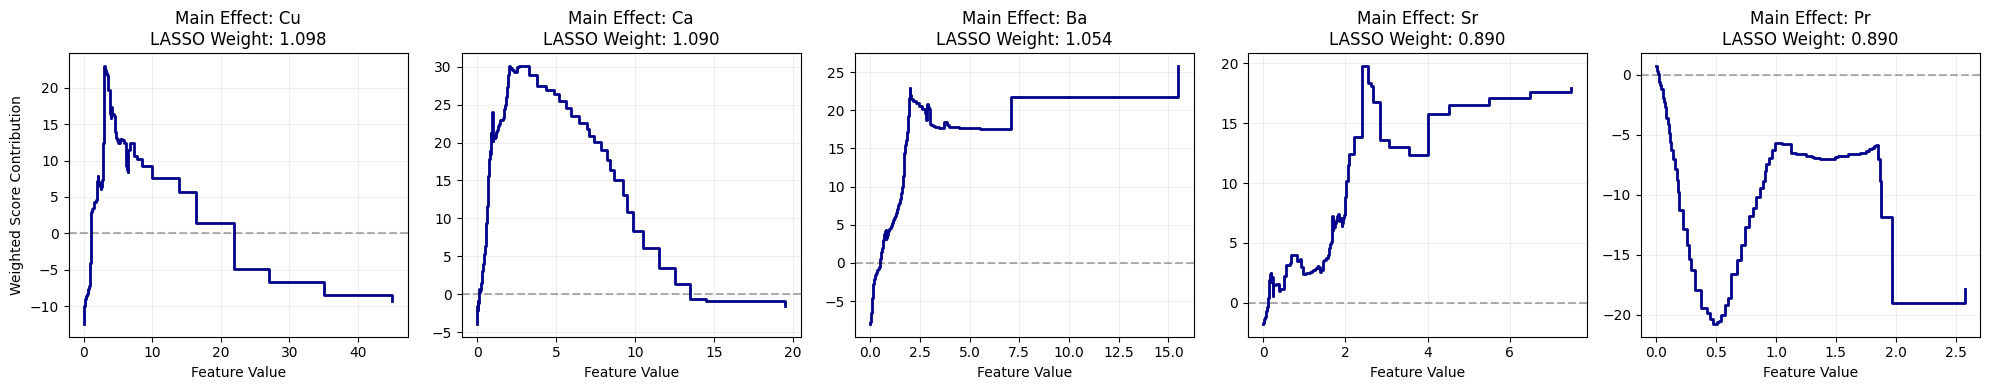

In [10]:
# 1. Get indices of non-zero coefficients after LASSO filtering (main effects only)
# Note: ebm.term_names_ contains both main effects and interaction terms.
# LASSO has weighted/filtered the contribution values of these terms.
tc_names = ebm.term_names_
lasso_coefs = ebm_lasso.coef_

# Identify features that are non-zero and categorized as "main effects"
# (excluding interaction terms which contain " & " in their names)
main_effect_indices = [
    i for i, (name, coef) in enumerate(zip(tc_names, lasso_coefs))
    if coef > 0 and " & " not in name
]

# Sort by LASSO weights (coef) and select the top 5 main effects
# Here we simply sort by the magnitude of the coefficients
sorted_main_indices = sorted(main_effect_indices, key=lambda i: lasso_coefs[i], reverse=True)[:5]

# 2. Plotting
n_plots = len(sorted_main_indices)
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=False)

# Ensure axes is a list if there is only one feature
if n_plots == 1:
    axes = [axes]

for i, idx in enumerate(sorted_main_indices):
    term_name = tc_names[idx]

    # Extract shape function data for the feature from the original EBM interpreter
    # ebm.explain_global() contains the contribution curves for all terms
    ebm_global = ebm.explain_global()
    data_dict = ebm_global.data(idx)

    x_vals = data_dict['names']
    # Key point: Final contribution = Original EBM contribution * LASSO weight coefficient
    y_vals = np.array(data_dict['scores']) * lasso_coefs[idx]

    # Draw step plots, which reflect the nature of EBM base learners (shallow trees)
    axes[i].step(x_vals[:-1], y_vals, where='post', color='darkblue', linewidth=2)

    # Chart styling
    axes[i].set_title(f"Main Effect: {term_name}\nLASSO Weight: {lasso_coefs[idx]:.3f}")
    axes[i].set_xlabel("Feature Value")
    if i == 0:
        axes[i].set_ylabel("Weighted Score Contribution")
    axes[i].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

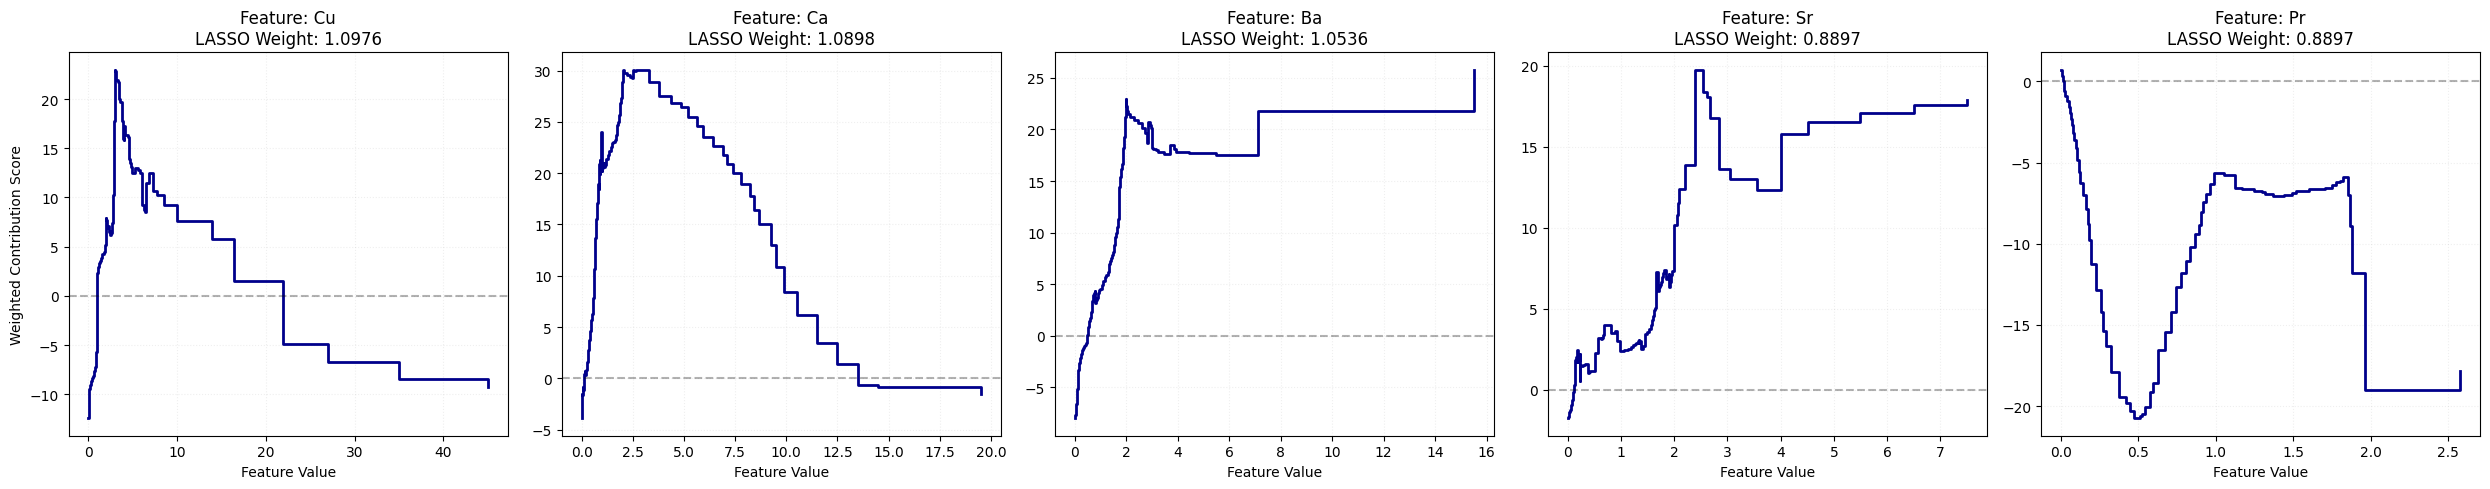

In [11]:
# 1. Get term names and LASSO coefficients
tc_names = ebm.term_names_
lasso_coefs = ebm_lasso.coef_

# Find indices where the coefficient is greater than 0 and the term is a main effect
# (excluding interaction terms containing " & " in the name)
main_effect_indices = [
    i for i, (name, coef) in enumerate(zip(tc_names, lasso_coefs))
    if coef > 0 and " & " not in name
]

# Sort by coefficient magnitude and take the top 5 most important features
sorted_main_indices = sorted(main_effect_indices, key=lambda i: lasso_coefs[i], reverse=True)[:5]

# 2. Plotting
n_plots = len(sorted_main_indices)
if n_plots == 0:
    print("No main effect features selected by LASSO were found.")
else:
    # Dynamically adjust canvas size to ensure labels do not overlap
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1: axes = [axes]

    # Obtain the global explanation object
    ebm_global = ebm.explain_global()

    for i, idx in enumerate(sorted_main_indices):
        # Extract feature name
        term_name = tc_names[idx]
        data_dict = ebm_global.data(idx)

        # Get bin boundaries and corresponding scores
        x_vals = np.array(data_dict['names'])
        # Final contribution = Original EBM score * LASSO weight coefficient
        y_vals = np.array(data_dict['scores']) * lasso_coefs[idx]

        # Fix dimension mismatch:
        # EBM 'names' (x) are usually bin boundaries and may have one more element than 'scores' (y)
        if len(x_vals) == len(y_vals) + 1:
            x_plot = x_vals[:-1]
            y_plot = y_vals
        else:
            x_plot = x_vals
            y_plot = y_vals

        # Draw step plots, reflecting the nature of EBM shape functions
        axes[i].step(x_plot, y_plot, where='post', color='darkblue', linewidth=2)

        # Explicitly display the feature name in the subplot title
        axes[i].set_title(f"Feature: {term_name}\nLASSO Weight: {lasso_coefs[idx]:.4f}", fontsize=12)

        # Draw baseline
        axes[i].axhline(0, color='black', linestyle='--', alpha=0.3)
        axes[i].set_xlabel("Feature Value", fontsize=10)

        if i == 0:
            axes[i].set_ylabel("Weighted Contribution Score", fontsize=10)

        axes[i].grid(True, alpha=0.2, linestyle=':')

    plt.tight_layout()
    plt.show()

## heat map

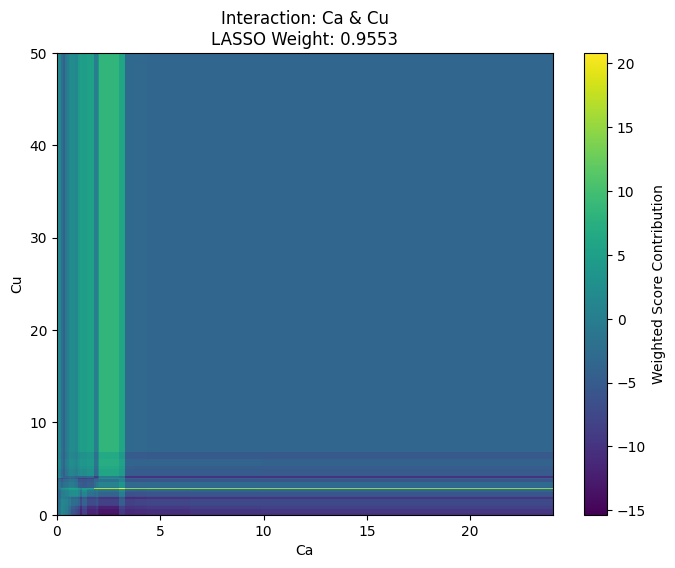

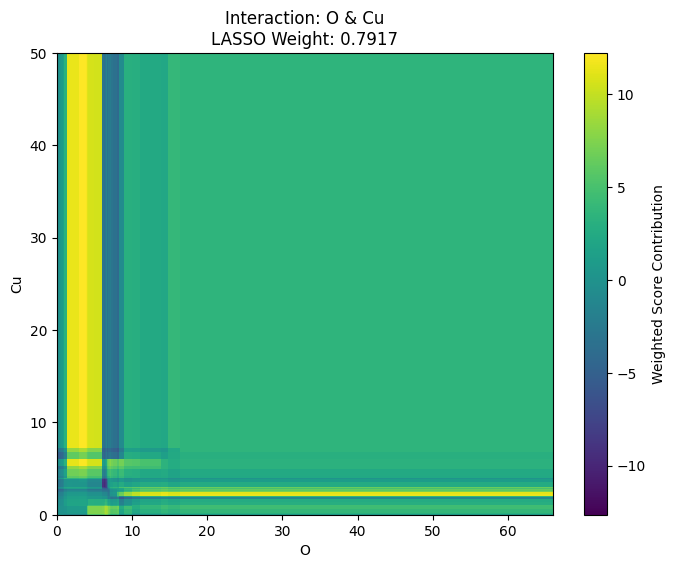

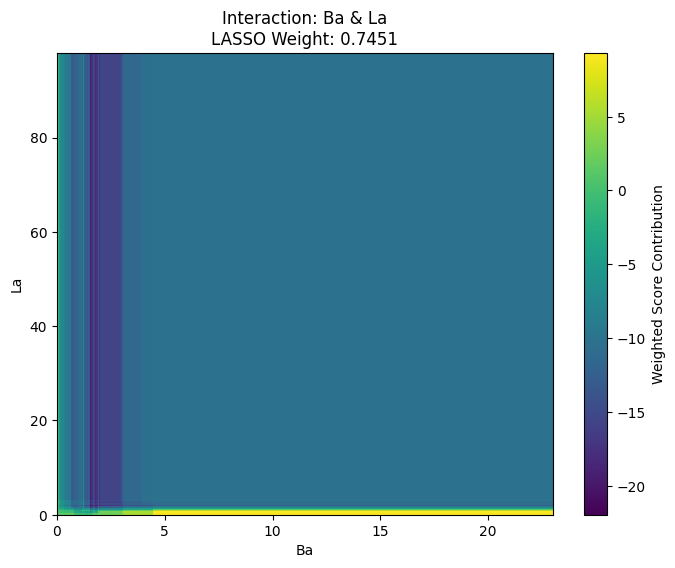

In [14]:
# 1. Get term names and LASSO coefficients
tc_names = ebm.term_names_
lasso_coefs = ebm_lasso.coef_

# Identify indices where the LASSO coefficient is greater than 0 and the term is an "interaction term"
# In the interpret library, interaction names typically contain " & "
interaction_indices = [
    i for i, (name, coef) in enumerate(zip(tc_names, lasso_coefs))
    if coef > 0 and " & " in name
]

# Sort by LASSO weight and select the top few (e.g., top 3)
sorted_inter_indices = sorted(interaction_indices, key=lambda i: lasso_coefs[i], reverse=True)[:3]

if len(sorted_inter_indices) == 0:
    print("No interaction terms selected by LASSO were found.")
else:
    ebm_global = ebm.explain_global()

    for idx in sorted_inter_indices:
        term_name = tc_names[idx]
        data_dict = ebm_global.data(idx)

        # Extract data required for 2D plotting
        # x_bins and y_bins correspond to the bin boundaries of the two interacting features
        x_bins = np.array(data_dict['left_names'])
        y_bins = np.array(data_dict['right_names'])
        # Final matrix contribution = Original score matrix * LASSO coefficient
        scores_matrix = np.array(data_dict['scores']) * lasso_coefs[idx]

        # Plotting
        plt.figure(figsize=(8, 6))
        # Use pcolormesh for plotting, which aligns with the nature of EBM 2D step functions
        im = plt.pcolormesh(x_bins, y_bins, scores_matrix.T, shading='auto', cmap='viridis')

        plt.colorbar(im, label='Weighted Score Contribution')
        plt.title(f"Interaction: {term_name}\nLASSO Weight: {lasso_coefs[idx]:.4f}")

        # Get specific feature names for axis labels
        features = term_name.split(' & ')
        plt.xlabel(features[0])
        plt.ylabel(features[1])

        # Use unique filenames for each interaction term to prevent overwriting
        file_name = f"interaction_{term_name.replace(' ', '_')}.pdf"
        plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=300)
        plt.show()

## Feature Importance Plot

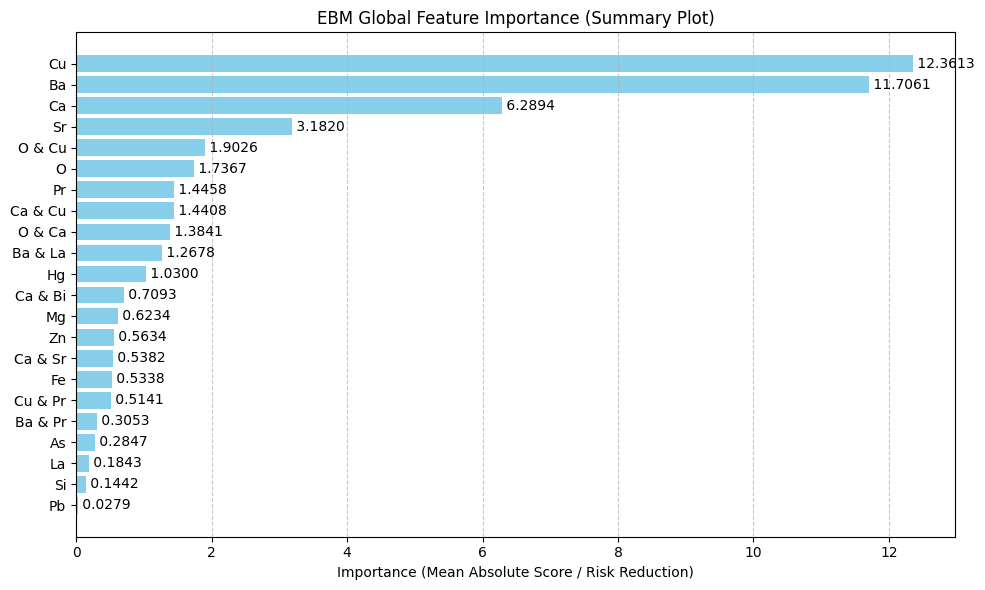

In [30]:
# 1. Extract feature names and corresponding importance scores
# term_names_ contains names for both main effects and interaction terms
names = ebm.term_names_
# term_importances() returns the contribution of each term to reducing loss
importances = ebm.term_importances()

# 2. Sort importance scores (descending order)
# We use ascending indices here so that when plotting a horizontal bar chart,
# the most important features appear at the top.
sorted_idx = np.argsort(importances)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center', color='skyblue')
plt.yticks(range(len(sorted_idx)), [names[i] for i in sorted_idx])

plt.xlabel('Importance (Mean Absolute Score / Risk Reduction)')
plt.title('EBM Global Feature Importance (Summary Plot)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Annotate numerical values
for i, v in enumerate(importances[sorted_idx]):
    plt.text(v, i, f' {v:.4f}', va='center', fontsize=10)

plt.tight_layout()
# saving as a vector graphic (PDF)
plt.savefig("ebm_summary_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()

## reason plot

In [31]:
# 假设我们要解释测试集中的第 0 条样本
sample_idx = 0
# 获取该样本经过项变换后的贡献值 (Term Contributions)
# X_tst_tc 是您之前计算出的 ebm.eval_terms(X_tst)
sample_tc = X_tst_tc[sample_idx]

# 获取项名称
tc_names = ebm.term_names_
# 获取 LASSO 权重系数（保持与您之前的 ebm_lasso 命名一致）
lasso_weights = ebm_lasso.coef_

# 计算经过 LASSO 修正后的实际贡献
# 实际贡献 = 原始项贡献 * LASSO 权重
final_contributions = sample_tc * lasso_weights

# 排序：找出对这条样本影响最大的前 10 个项（按绝对值排序）
top_indices = np.argsort(np.abs(final_contributions))[::-1][:10]

# 准备绘图数据
plot_names = [tc_names[i] for i in top_indices]
plot_contribs = final_contributions[top_indices]

# 绘图
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in plot_contribs]
plt.barh(range(len(plot_names)), plot_contribs, color=colors, align='center')
plt.yticks(range(len(plot_names)), plot_names)

# 添加截距信息（Base Value）
intercept = ebm_lasso.intercept_
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f"Reason Plot for Sample {sample_idx}\n(Base Value: {intercept:.2f}, Pred: {ebm_lasso.predict(X_tst_tc[sample_idx:sample_idx+1])[0]:.2f})")
plt.xlabel("Contribution to Prediction Score")
plt.gca().invert_yaxis() # 让影响力最大的排在上面
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 标注数值
for i, v in enumerate(plot_contribs):
    plt.text(v, i, f' {v:+.3f}', va='center', color='black', fontweight='bold' if abs(v) > 0.1 else 'normal')

plt.tight_layout()
# 保存为矢量图
plt.savefig(f"ebm_reason_plot_sample_{sample_idx}.pdf", format='pdf', bbox_inches='tight')
plt.show()

IndexError: list index out of range

## 特征分箱

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (202,) and arg 1 with shape (22,).

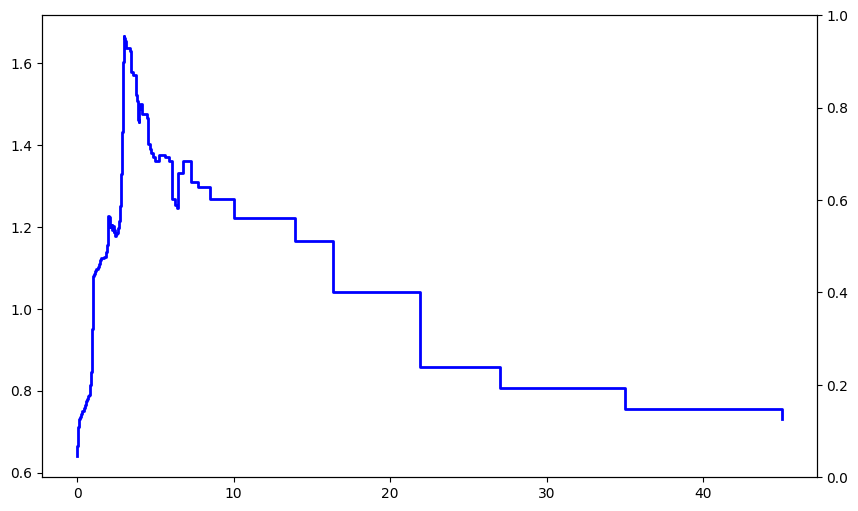

In [37]:
def plot_feature_binning_analysis(ebm, X, y, feature_name):
    # 1. 获取该特征在 EBM 中的全局解释数据
    ebm_global = ebm.explain_global()
    idx = ebm.term_names_.index(feature_name)
    data_dict = ebm_global.data(idx)

    # 形状函数数据 (Smoothed Factors)
    bin_names = np.array(data_dict['names'])
    scores = np.array(data_dict['scores'])

    # 2. 计算地面真值均值 (y_mean)
    # 使用 pd.cut 按照 EBM 的分箱边界对 X 进行分箱
    # 注意：边界处理需根据 ebm 的具体 binning 结果微调
    df = pd.DataFrame({feature_name: X[feature_name], 'y': y})
    # 这里简化处理：直接获取每个 bin 的样本 y 均值
    # 在实际科研中，需确保 bin 的定义与 ebm 内部完全一致
    y_global_mean = np.mean(y)

    # 标准化：除以全局均值
    norm_scores = (scores + ebm.intercept_) / y_global_mean

    # 3. 绘图
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 绘制平滑因子 (Smoothed Factors) - 阶梯图
    # 修正维度：x 为边界，y 为分箱得分
    ax1.step(bin_names[:-1], norm_scores, where='post', color='blue', label='Predicted Factor (Smoothed)', linewidth=2)

    # 绘制地面真值均值 (Ground Truth Mean) - 散点或折线
    # ax1.scatter(bin_names[:-1], norm_y_means, color='red', alpha=0.5, label='Actual Mean (Ground Truth)')

    # 绘制样本量分布 (Density/Count) - 柱状图在次坐标轴
    ax2 = ax1.twinx()
    # 假设 data_dict 中有密度信息，通常 EBM 会存储分箱内的样本密度
    if 'density' in data_dict:
        ax2.bar(bin_names[:-1], data_dict['density']['scores'], width=np.diff(bin_names),
                alpha=0.2, color='gray', label='Sample Density')

    # 图表修饰
    ax1.axhline(1.0, color='black', linestyle='--', alpha=0.3)
    ax1.set_xlabel(f"Feature Value: {feature_name}")
    ax1.set_ylabel("Standardized Factor (Rel. to Global Mean)")
    ax2.set_ylabel("Sample Density")
    ax1.set_title(f"Feature Binning Analysis: {feature_name}")
    ax1.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f"binning_analysis_{feature_name}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# 调用函数
plot_feature_binning_analysis(ebm, X_trn, y_trn, "Cu")